Folder `./notebooks/hpo/gridsearch/results/checkpoints` perlu dihapus jika terdapat perubahan pada dataset atau konfigurasi search space. Jika tidak, maka program akan load hasil dari run sebelumnya. Jadi konfigurasi terbaru hanya akan teraplikasikan pada konfigurasi yang belum atau belum selesai dijalankan.

- Sebelum program dijalankan, buat direktori `./dataset` pada root dir dan upload dataset
- Copy `.env.example` dan rename ke `.env`. Lalu ubah value dari variable `PROJECT_ROOT` menjadi absolute path ke project ini

In [1]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
project_root = Path(os.environ["PROJECT_ROOT"])
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data

# import sys
# import os

# # Add project root (210226) to Python path
# sys.path.append(os.path.abspath("../../.."))

# from utils.prepare_data import prepare_data

Project root: c:\`Bioinformatics\quantum-gesang\codes


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [4]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [5]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [6]:
import numpy as np

In [7]:
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

## Utility

In [8]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

In [9]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/pqk")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"quantum_{name}.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


In [10]:
import pickle
from pathlib import Path

# Checkpoint dir — sama strukturnya kayak log_dir tapi pakai .pkl
ckpt_dir = Path("./results/checkpoints/scalability")  # ganti path sesuai notebook
ckpt_dir.mkdir(parents=True, exist_ok=True)

def load_checkpoint(name):
    """Load checkpoint kalau ada, return dict kosong kalau belum ada."""
    ckpt_path = ckpt_dir / f"quantum_{name}.pkl"
    if ckpt_path.exists():
        with open(ckpt_path, "rb") as f:
            data = pickle.load(f)
        log(f"♻️  Resumed checkpoint: {ckpt_path} ({len(data['done_configs'])} configs done)")
        return data, ckpt_path
    return {"done_configs": {}, "results": [], "best_result": None, "best_score": -np.inf}, ckpt_path

def save_checkpoint(ckpt_path, data):
    """Save progress atomically (tulis ke .tmp dulu, lalu rename)."""
    tmp = ckpt_path.with_suffix(".pkl.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(data, f)
    tmp.replace(ckpt_path)  # atomic on most filesystems

## Scalability

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    precision_score, recall_score
)

# ── Konfigurasi scalability ───────────────────────────────────────────────────
scalability_datasets = {
    500:   os.path.join(project_root, "dataset", "Dataset_TehHijau500.csv"),
    1000:  os.path.join(project_root, "dataset", "Dataset_TehHijau1k.csv"),
    5000:  os.path.join(project_root, "dataset", "Dataset_TehHijau5k.csv"),
    10000: os.path.join(project_root, "dataset", "Dataset_TehHijau.csv"),
}
scalability_kernels   = ['custom', 'full']
scalability_params    = {'C': 1, 'lambda_': 0.3}
scal_n_splits         = 5
scal_state            = 42
 
 
def run_scalability(QKERNEL: str, mode: str):
    """
    Evaluasi QSVC dengan kernel QKERNEL pada semua ukuran dataset.

    Returns:
        dict berisi kernel, mode, done_configs, results, best_result, best_score
        — siap dipakai langsung oleh `plot_scalability_comparison`.
    """
    setup_logger(f"scalability_qsvc_{QKERNEL}_{mode}")
 
    sizes      = list(scalability_datasets.keys())
    total_runs = len(sizes)
 
    log(f"🔬 Kernel: {QKERNEL}  | Mode: {mode}  |  Sizes: {sizes}  |  Folds: {scal_n_splits}")
    log( "   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")
 
    # ── Resume dari checkpoint ─────────────────────────────────────────────────
    # File checkpoint sudah ter-namespaced per (kernel, mode) lewat nama file,
    # jadi tag cukup pakai (size, kernel).
    ckpt, ckpt_path = load_checkpoint(f"scalability_qsvc_{QKERNEL}_{mode}")
    done_configs    = ckpt["done_configs"]   # {size: {agg_metrics...}}
    results         = ckpt["results"]        # list of per-fold dicts
    best_result     = ckpt["best_result"]
    best_score      = ckpt["best_score"]
 
    # ── Loop tiap ukuran dataset ──────────────────────────────────────────────
    for i, (size, ds_path) in enumerate(scalability_datasets.items(), 1):
        tag = f"size={size} | kernel={QKERNEL}"
 
        if tag in done_configs:
            log(f"\n  ⏭️  [{i}/{total_runs}] {tag}  (skipped, already done)")
            continue
 
        log(f"\n  ▶ [{i}/{total_runs}] {tag}")
        _iter_t0 = time.perf_counter()
 
        # ── Load & prep dataset ────────────────────────────────────────────────
        df_s  = pd.read_csv(ds_path)
        X_s   = df_s[feature_cols]
        y_s   = LabelEncoder().fit_transform(df_s[target_cols])
        n_opt_s = plot_pca_variance(X_s, n_components=X_s.shape[1], threshold=0.95)
        log(f"   Shape: X={X_s.shape}  |  n_optimal={n_opt_s}")
 
        skf_s = StratifiedKFold(n_splits=scal_n_splits, shuffle=True,
                                random_state=scal_state)
 
        # ── Akumulasi per-fold ─────────────────────────────────────────────────
        accs, f1s, rocs, pras, precs, recs = [], [], [], [], [], []
        y_val_all, y_pred_all              = [], []
 
        for fold, (tr_idx, va_idx) in enumerate(skf_s.split(X_s, y_s), 1):
            X_tr, X_va = X_s.iloc[tr_idx], X_s.iloc[va_idx]
            y_tr, y_va = y_s[tr_idx],      y_s[va_idx]
 
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('pca',    PCA(n_components=n_opt_s)),
                ('svc',    QSVCWrapper(
                    kernel=QKERNEL, mode=mode,
                    n_qubits=n_opt_s, n_features=n_opt_s,
                    random_state=scal_state,
                    decision_function_shape='ovr',
                    **scalability_params,
                )),
            ])
            model.fit(X_tr, y_tr)
 
            y_pred = model.predict(X_va)
            y_prob = model.predict_proba(X_va)
 
            y_val_all.extend(y_va)
            y_pred_all.extend(y_pred)
 
            acc  = accuracy_score(y_va, y_pred)
            f1   = f1_score(y_va, y_pred, average='weighted')
            roc  = roc_auc_score(y_va, y_prob, average='weighted', multi_class='ovr')
            pra  = average_precision_score(y_va, y_prob, average='weighted')
            prec = precision_score(y_va, y_pred, average='weighted', zero_division=0)
            rec  = recall_score(y_va, y_pred, average='weighted', zero_division=0)
 
            accs.append(acc);  f1s.append(f1)
            rocs.append(roc);  pras.append(pra)
            precs.append(prec); recs.append(rec)
 
            log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | "
                f"Rec={rec:.4f} | F1={f1:.4f} | "
                f"AUROC={roc:.4f} | PRAUC={pra:.4f}")
 
            results.append({
                "tag":       tag,
                "size":      size,
                "kernel":    QKERNEL,
                "fold":      fold,
                "accuracy":  acc,
                "precision": prec,
                "recall":    rec,
                "F1":        f1,
                "auroc":     roc,
                "prauc":     pra,
            })
 
        # ── Agregat ────────────────────────────────────────────────────────────
        acc_mean,  acc_std  = np.mean(accs),  np.std(accs)
        prec_mean, prec_std = np.mean(precs), np.std(precs)
        rec_mean,  rec_std  = np.mean(recs),  np.std(recs)
        f1_mean,   f1_std   = np.mean(f1s),   np.std(f1s)
        roc_mean,  roc_std  = np.mean(rocs),  np.std(rocs)
        pra_mean,  pra_std  = np.mean(pras),  np.std(pras)
        mcc                 = matthews_corrcoef(y_val_all, y_pred_all)
        composite           = (roc_mean + pra_mean + acc_mean) / 3
        iter_time           = time.perf_counter() - _iter_t0
 
        log(
            f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
            f"Precision:{prec_mean:.4f}±{prec_std:.4f} | "
            f"Recall:{rec_mean:.4f}±{rec_std:.4f} | "
            f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
            f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
            f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
            f"MCC:{mcc:.4f} | "
            f"Composite:{composite:.4f} | "
            f"Time:{iter_time:.1f}s"
        )
 
        # ── Update best ────────────────────────────────────────────────────────
        if composite > best_score:
            best_score  = composite
            best_result = {
                'tag':            tag,
                'composite':      composite,
                'roc':            f"{roc_mean:.4f}±{roc_std:.4f}",
                'pra':            f"{pra_mean:.4f}±{pra_std:.4f}",
                'acc':            f"{acc_mean:.4f}±{acc_std:.4f}",
                'f1':             f"{f1_mean:.4f}±{f1_std:.4f}",
                'prec':           f"{prec_mean:.4f}±{prec_std:.4f}",
                'rec':            f"{rec_mean:.4f}±{rec_std:.4f}",
                'size':           size,
                'execution_time': iter_time,
            }
 
        # ── Simpan ke checkpoint ───────────────────────────────────────────────
        done_configs[tag] = {
            "composite": composite,
            "size":      size,
            "kernel":    QKERNEL,
            "acc_mean":  acc_mean,   "acc_std":  acc_std,
            "prec_mean": prec_mean,  "prec_std": prec_std,
            "rec_mean":  rec_mean,   "rec_std":  rec_std,
            "f1_mean":   f1_mean,    "f1_std":   f1_std,
            "roc_mean":  roc_mean,   "roc_std":  roc_std,
            "pra_mean":  pra_mean,   "pra_std":  pra_std,
            "mcc":       mcc,
            "exec_time": iter_time,
            "n_optimal": n_opt_s,
        }
        save_checkpoint(ckpt_path, {
            "done_configs": done_configs,
            "results":      results,
            "best_result":  best_result,
            "best_score":   best_score,
        })
 
    # ── Ringkasan akhir ────────────────────────────────────────────────────────
    if best_result is not None:
        log(f"\n🏆 Best config : {best_result['tag']}")
        log(
            f"   Composite   : {best_result['composite']:.4f} "
            f"(AUROC={best_result['roc']} | "
            f"PRAUC={best_result['pra']} | "
            f"Acc={best_result['acc']} | "
            f"Prec={best_result['prec']} | "
            f"Rec={best_result['rec']})"
        )

    return {
        "kernel":       QKERNEL,
        "mode":         mode,
        "done_configs": done_configs,
        "results":      results,
        "best_result":  best_result,
        "best_score":   best_score,
    }

In [12]:
def plot_scalability_comparison(*runs, metrics=None, save_path=None):
    """
    Plot skalabilitas untuk N hasil `run_scalability` sekaligus dalam 1 figure.

    Usage:
        custom_pqk = run_scalability('custom', 'pqk')
        full_pqk   = run_scalability('full',   'pqk')
        custom_fsk = run_scalability('custom', 'fsk')
        plot_scalability_comparison(custom_pqk, full_pqk, custom_fsk)

    Args:
        *runs    : N hasil dari `run_scalability` (dict berisi
                   'kernel', 'mode', 'done_configs').
        metrics  : list metrik yang diplot (default: 6 metrik standar).
        save_path: kalau diisi, simpan figure ke path tsb.
    """
    if not runs:
        raise ValueError("plot_scalability_comparison butuh minimal 1 hasil run.")

    if metrics is None:
        metrics = ['acc_mean', 'f1_mean', 'roc_mean', 'pra_mean', 'prec_mean', 'rec_mean']

    metric_labels = {
        'acc_mean':  'Accuracy',
        'f1_mean':   'F1 Score',
        'roc_mean':  'AUROC',
        'pra_mean':  'PRAUC',
        'prec_mean': 'Precision',
        'rec_mean':  'Recall',
    }
    std_keys = {k: k.replace('_mean', '_std') for k in metrics}

    # style preset utk kombinasi umum; di luar itu pakai fallback palette
    preset_styles = {
        ('custom', 'pqk'): {'color': '#5B4FCF', 'marker': 'o', 'linestyle': '-'},
        ('full',   'pqk'): {'color': '#1D9E75', 'marker': 's', 'linestyle': '-'},
        ('custom', 'fsk'): {'color': '#E67E22', 'marker': '^', 'linestyle': '--'},
        ('full',   'fsk'): {'color': '#C0392B', 'marker': 'D', 'linestyle': '--'},
    }
    fallback_palette = ['#3498DB', '#9B59B6', '#16A085', '#F39C12',
                        '#7F8C8D', '#2C3E50', '#E84393', '#00B894']
    fallback_markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

    def style_for(kernel, mode, idx):
        if (kernel, mode) in preset_styles:
            return preset_styles[(kernel, mode)]
        return {
            'color':     fallback_palette[idx % len(fallback_palette)],
            'marker':    fallback_markers[idx % len(fallback_markers)],
            'linestyle': '-' if mode == 'pqk' else '--',
        }

    sizes    = sorted(scalability_datasets.keys())
    x        = np.arange(len(sizes))
    x_labels = [f"{s//1000}k" if s >= 1000 else str(s) for s in sizes]

    # ── Figure ────────────────────────────────────────────────────────────────
    n_metrics = len(metrics)
    ncols     = 3
    nrows     = (n_metrics + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5 * ncols, 4 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, metric in zip(axes, metrics):
        for idx, run in enumerate(runs):
            kernel = run["kernel"]
            mode   = run["mode"]
            rows   = {rec["size"]: rec for rec in run["done_configs"].values()}

            ys   = np.array([rows[s][metric]           if s in rows else np.nan for s in sizes])
            errs = np.array([rows[s][std_keys[metric]] if s in rows else np.nan for s in sizes])

            style = style_for(kernel, mode, idx)

            ax.plot(x, ys,
                    label=f"QSVC-{kernel.upper()} ({mode.upper()})",
                    color=style['color'],
                    marker=style['marker'],
                    linestyle=style['linestyle'],
                    markersize=6,
                    linewidth=1.8)
            ax.fill_between(x, ys - errs, ys + errs,
                            color=style['color'], alpha=0.10)

        ax.set_title(metric_labels.get(metric, metric), fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_xlabel("Jumlah sampel", fontsize=10)
        ax.set_ylabel("Mean ± Std", fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=8)

    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle(
        f"Skalabilitas QSVC  "
        f"(C={scalability_params['C']}, λ={scalability_params['lambda_']})",
        fontsize=13, fontweight='bold'
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        log(f"📊 Plot disimpan → {save_path}")

    plt.show()
    # return fig

📝 Log: results\logs\pqk\quantum_scalability_qsvc_full_pqk.log
🕒 Started: 2026-05-31T19:25:19
🔬 Kernel: full  | Mode: pqk  |  Sizes: [500, 1000, 5000, 10000]  |  Folds: 5
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3
♻️  Resumed checkpoint: results\checkpoints\scalability\quantum_scalability_qsvc_full_pqk.pkl (8 configs done)

  ⏭️  [1/4] size=500 | kernel=full  (skipped, already done)

  ⏭️  [2/4] size=1000 | kernel=full  (skipped, already done)

  ⏭️  [3/4] size=5000 | kernel=full  (skipped, already done)

  ⏭️  [4/4] size=10000 | kernel=full  (skipped, already done)

🏆 Best config : size=10000 | kernel=full  | mode=pqk
   Composite   : 0.9814 (AUROC=0.9964±0.0008 | PRAUC=0.9887±0.0023 | Acc=0.9592±0.0033 | Prec=0.9597±0.0031 | Rec=0.9592±0.0033)
📝 Log: results\logs\pqk\quantum_scalability_qsvc_full_fsk.log
🕒 Started: 2026-05-31T19:25:19
🔬 Kernel: full  | Mode: fsk  |  Sizes: [500, 1000, 5000, 10000]  |  Folds: 5
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3
♻️  Resumed 

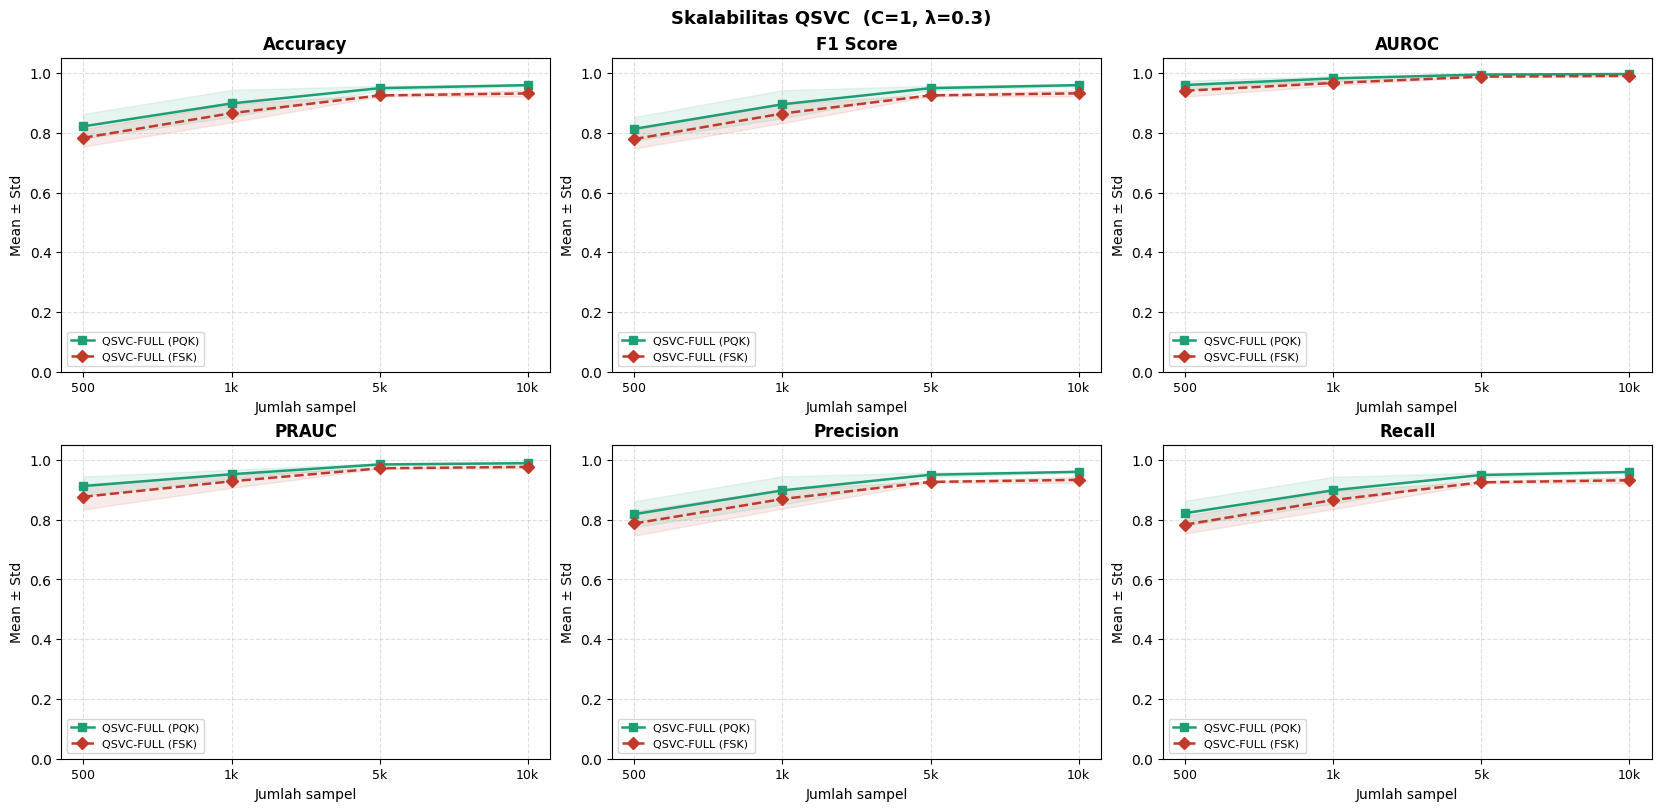

In [13]:
# custom_pqk = run_scalability('custom_full', 'pqk')
full_pqk   = run_scalability('full',   'pqk')
# linear_pqk = run_scalability('custom_linear', 'pqk')
# circular_pqk = run_scalability('custom_circular', 'pqk')
# custom_fsk = run_scalability('custom_full', 'fsk')
full_fsk   = run_scalability('full',   'fsk')


plot_scalability_comparison(full_pqk, full_fsk)